In [1]:
import cv2
import numpy as np
import torch
from PIL import Image
import sys
sys.path.append("..")
from rich import print
from dataset import SCARED,HighlightDataset
from dataset.highlight import draw_rect
from utilities.visualization import rgb, panelize
from geometry import euler2mat as e2m
import random
%load_ext autoreload
%autoreload 2

In [38]:
dataset = HighlightDataset(
    SCARED(
        # There are 10 frames of SCARED in the dataset/sample_datasets/SCARED/ directory
        path="/datasets/SCARED",
        vids=SCARED.videonames(),
        frameskip=[1],
        height=448,
        width=448,
        with_depth=True,
    ),
    brightness_threshold=0.9,
    rect_size=(384, 384),
    return_mask=True,
    return_rect=True
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)#, sampler=dataset.sampler)
iloader = iter(dataloader)
sample = next(iloader)
print({k:v.shape if isinstance(v,torch.Tensor) else v for k,v in sample.items()})

{
    'idx': torch.Size([1]),
    'framestack': torch.Size([1, 2, 3, 448, 448]),
    'Ts2t': torch.Size([1, 6]),
    'depthstack': torch.Size([1, 2, 1, 448, 448]),
    'paths': [
        ('/datasets/SCARED/v21/poses_absolute/000428.json',),
        ('/datasets/SCARED/v21/poses_absolute/000429.json',)
    ],
    'frameskip': torch.Size([1]),
    'intrinsics': torch.Size([1, 3, 3]),
    'Ts': torch.Size([1, 4, 4]),
    'Tt': torch.Size([1, 4, 4]),
    'highlight_masks': torch.Size([1, 2, 1, 448, 448]),
    'highlight_coverage': torch.Size([1, 2]),
    'rect_coords': torch.Size([1, 2, 4]),
    'rect_crop': torch.Size([1, 2, 3, 384, 384]),
    'rect_mask': torch.Size([1, 2, 1, 384, 384])
}

Percentage of highlighted pixels in output: 0.5853723883628845%

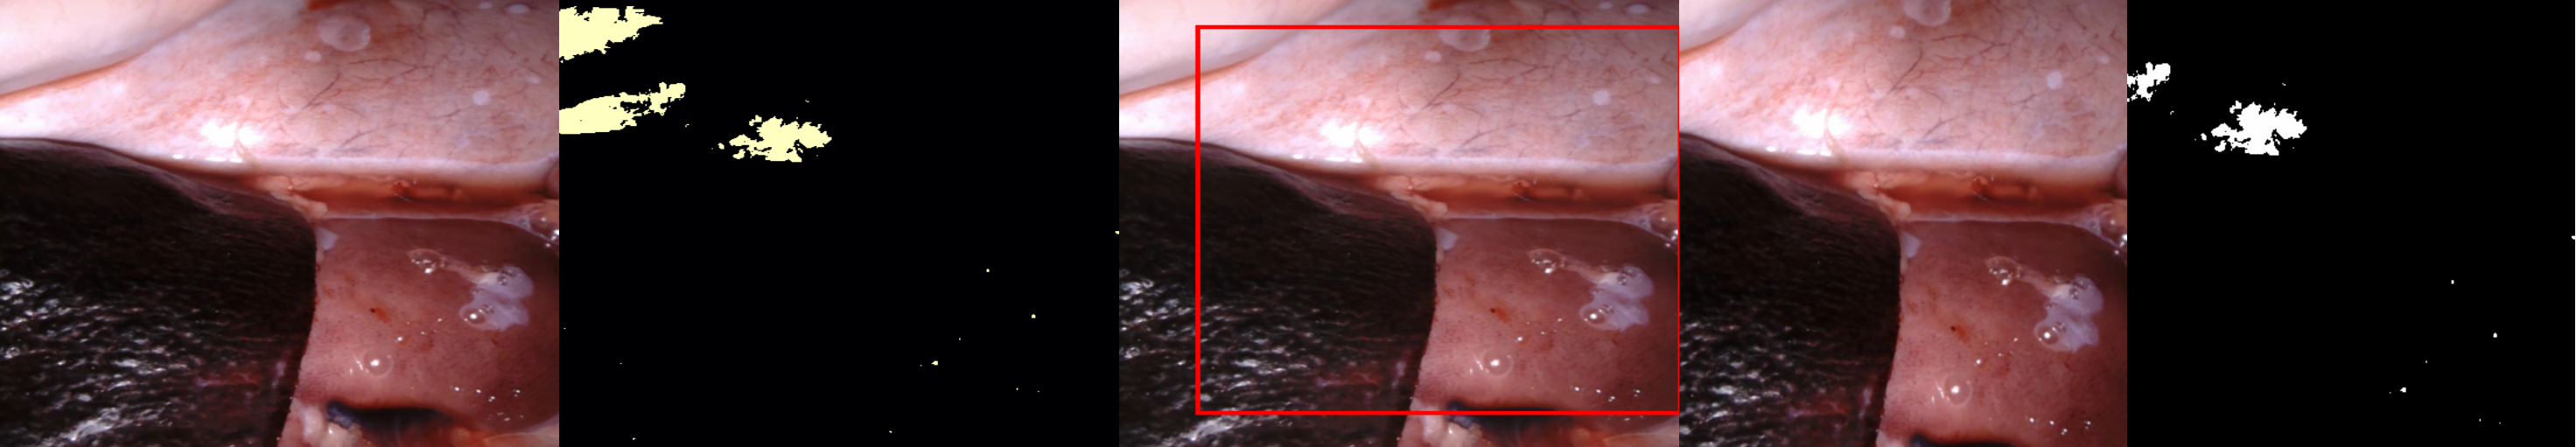

In [39]:
sample = next(iloader)
print(
    f"Percentage of highlighted pixels in output: {sample['rect_mask'][0].sum() / sample['rect_crop'][0].numel()*100}%"
)
rgb(
    panelize(
        rgb(
            sample["framestack"][0, 0],
            resize=(512, 640),
            as_tensor=True,
        ),
        rgb(
            sample["highlight_masks"][0, 0],
            resize=(512, 640),
            as_tensor=True,
        ),
        rgb(
            draw_rect(
                sample["framestack"][0, 0], (255, 0, 0), 4, sample["rect_coords"][0, 0]
            ),
            resize=(512, 640),
            as_tensor=True,
        ),
        rgb(sample["rect_crop"][0, 0], resize=(512, 512), as_tensor=True),
        rgb(
            sample["rect_mask"][0, 0],
            resize=(512, 512),
            as_tensor=True,
            colormap="gray",
        ),
        resize_to_match=False,
    )
)

In [40]:
import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name
).cuda()
model.config.image_size = (448,448)
inputs = processor(images=image, return_tensors="pt").to(model.device)
inputs["pixel_values"] = sample["framestack"][:1,0].cuda()
with torch.inference_mode():
    outputs = model(**inputs)

pooled_output = outputs.pooler_output
lhs = outputs.last_hidden_state
print("Pooled output shape:", pooled_output.shape)
print("Last hidden state shape:", lhs.shape)


Pooled output shape:
torch.Size([1, 768])

Last hidden state shape:
torch.Size([1, 789, 768])

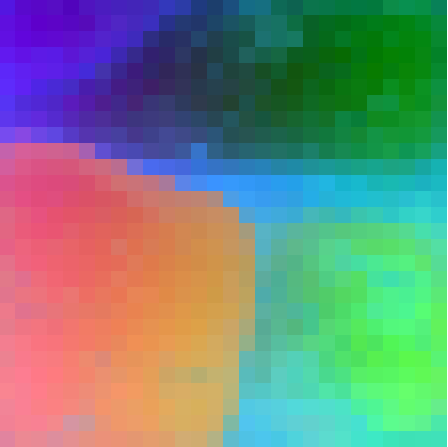

In [41]:
from utilities import embedding2color, embedding2chw
rgb(embedding2color(embedding2chw(lhs[:,5:]))[0],scale=16)

In [25]:
embedding2chw(lhs[:,1:]).shape

torch.Size([1, 768, 20, 29])

In [19]:
lhs.shape

torch.Size([1, 581, 768])

In [9]:
224/16*14

196.0

In [ ]:
import rerun as rr
import rerun.blueprint as rrb
rr.init("Point Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),6
        )
    )
)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)
rr.set_time("frame", sequence=0)


In [5]:
import projections
from pipelines.depth.depth import DepthPipeline
from dotmap import DotMap
import yaml
### Load Sample
# sample = next(iloader)
### Load Configuration
# We load the configuration from the YAML file and convert it to a DotMap for easy access.
CONFIG_PATH = '../config.yaml'
with open(CONFIG_PATH, 'r') as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml['parameters']
    config_training_dict = {k: v.get('value') for k, v in config_parameters.items() if v is not None}
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(config.IMAGE_HEIGHT,config.IMAGE_WIDTH).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT,config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 20
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config,model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:,0].cuda())
K = sample["intrinsics"][0].cuda()

### Parameters
LIGHT_INTENSITY = 100.0
LIGHT_COLOR = torch.tensor([1.0,1.0,1.0]).cuda()
SURFACE_SHININESS = 0.8
REFLECTION_STRENGTH = 0.5

light_position_start = 10 * torch.randn(3).cuda()
light_position_end = 10 * torch.randn(3).cuda()

### Parameters
for light_sample in range(50):
    rr.set_time("frame", sequence=light_sample)
    POINT_LIGHT_POSITION = light_position_start + (light_position_end - light_position_start) * light_sample / 50
    xyz1, _, rgbvec = backproject(
        sample["rect_crop"][:,0].cuda(),
        cropdepth,
        torch.inverse(K).unsqueeze(0),
    ).values()
    refres = highlighter.forward_point_light(
        cloud=xyz1,
        rgb_vec=rgbvec,
        camera_K=K.unsqueeze(0),
        camera_T=torch.eye(4).unsqueeze(0).cuda(),
        light_position=POINT_LIGHT_POSITION,  
        light_intensity=LIGHT_INTENSITY,  
        light_color=LIGHT_COLOR,  
        surface_roughness=SURFACE_SHININESS,  
        reflection_strength=REFLECTION_STRENGTH,  
    )

    rr.log(
        "/3d/cloud",
        rr.Points3D(
            positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
            colors=rgbvec[0].permute(1, 0).cpu().numpy(),
        ),
        static=True,
    )
    rr.log(
        "/3d/cam",
        rr.Pinhole(
            image_from_camera=K.cpu(),  # (3, 3)
            resolution=(384, 384),  # (2,)
            camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
        ),
        static=True,
    )

    all_reflections = refres["reflection_only"][0].mean(0,keepdim=True)
    all_reflections[sample["rect_mask"][0,0]==1]=1.5
    rr.log(
        f"/ref",
        rr.Image(
            rgb(all_reflections, as_tensor=True,colormap="jet")
            .permute(2,1,0)
            .cpu()
            .numpy()
        ),
    )
    rr.log(
        f"/source",
        rr.Image(rgb(sample["rect_crop"][0,0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True).permute(2,1,0).cpu().numpy()),
    )
    rr.log(
        f"/sourceref",
        rr.Image(
            rgb(refres["warped"][0], as_tensor=True).permute(2,1,0).cpu().numpy()
        ),
    )
    rr.log(
        f"/3d/light",
        rr.Points3D(
            positions=POINT_LIGHT_POSITION.cpu().numpy(),
            colors=LIGHT_COLOR.cpu().numpy(),
            radii=2,
        ),
    )
    # rgb(
    #     panelize(
    #         rgb(sample["rect_crop"][0,0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True),
    #         rgb(refres["warped"][0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True),
    #         rgb(refres["reflection_only"][0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True,colormap="gray"),
    #     )
    # )

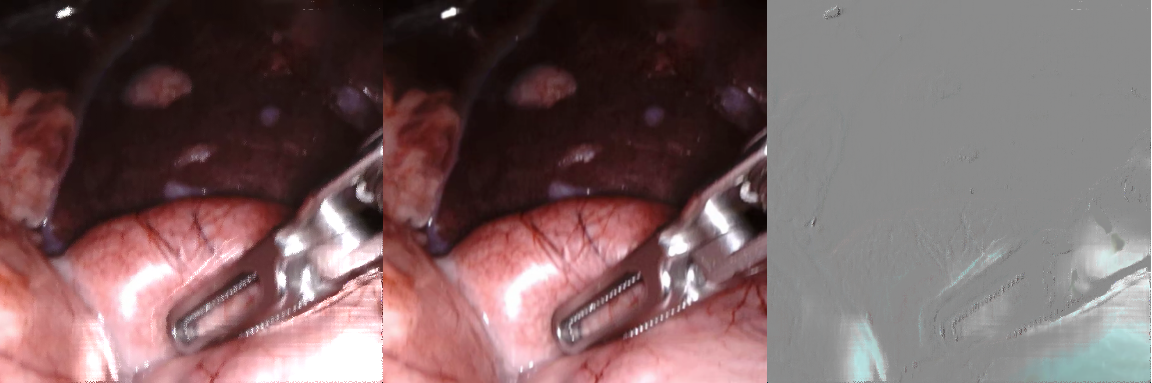

In [6]:
both = refres["warped"][0].cpu()
orig = sample["rect_crop"][:, 0].cpu()
diff = both - orig
rgb(
    panelize(
        rgb(both, as_tensor=True), rgb(orig, as_tensor=True), rgb(diff, as_tensor=True)
    )
)

In [7]:
import rerun as rr
import rerun.blueprint as rrb
rr.init("Planar Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
        )
    )
)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)
rr.set_time("frame", sequence=0)


In [8]:
import projections
from pipelines.depth.depth import DepthPipeline
from dotmap import DotMap
import yaml
import torch
import numpy as np

### Load Sample
# sample = next(iloader)

### Load Configuration
CONFIG_PATH = '../config.yaml'
with open(CONFIG_PATH, 'r') as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml['parameters']
    config_training_dict = {k: v.get('value') for k, v in config_parameters.items() if v is not None}
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(config.IMAGE_HEIGHT, config.IMAGE_WIDTH).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT, config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 20
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config, model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:,0].cuda())
K = sample["intrinsics"][0].cuda()

light_position = 10 * torch.randn(3).cuda()-10
light_eulangs = 5*torch.randn(3).cuda()
light_eulangs[-1] = torch.abs(light_eulangs[-1])
LIGHT_POSE = torch.cat([light_position,light_eulangs],dim=0)
LIGHT_POSE_START = LIGHT_POSE.unsqueeze(0)

light_position = 5 * torch.randn(3).cuda()-10
light_eulangs = 0.1*torch.randn(3).cuda()
light_eulangs[-1] = torch.abs(light_eulangs[-1])
LIGHT_POSE = torch.cat([light_position,light_eulangs],dim=0)
LIGHT_POSE_END = LIGHT_POSE.unsqueeze(0)

LIGHT_WIDTH = 100      # Width of rectangular light (in meters)
LIGHT_HEIGHT = 80     # Height of rectangular light (in meters)
LIGHT_SAMPLES = 10*8
for light_sample in range(50):
    rr.set_time("frame", sequence=light_sample)
    LIGHT_POSE_EUL = LIGHT_POSE_START + (LIGHT_POSE_END - LIGHT_POSE_START) * light_sample / 50
    ### Planar Light Parameters
    LIGHT_INTENSITY = 10.0/LIGHT_SAMPLES
    LIGHT_COLOR = torch.tensor([1.0, 1.0, 1.0]).cuda()
    SURFACE_SHININESS = 0.8
    REFLECTION_STRENGTH = 0.1

    # Create planar light pose matrix
    # Position the light at a random location similar to your point light
    LIGHT_POSE = e2m(LIGHT_POSE_EUL)

    ### Backproject and render with planar light
    xyz1, _, rgbvec = backproject(
        sample["rect_crop"][:,0].cuda(),
        cropdepth,
        torch.inverse(K).unsqueeze(0),
    ).values()

    refres = highlighter.forward_planar_light(
        cloud=xyz1,
        rgb_vec=rgbvec,
        camera_K=K.unsqueeze(0),
        camera_T=torch.eye(4).unsqueeze(0).cuda(),
        light_pose=LIGHT_POSE,
        light_width=LIGHT_WIDTH,
        light_height=LIGHT_HEIGHT,
        light_samples=LIGHT_SAMPLES,
        light_intensity=LIGHT_INTENSITY,
        light_color=LIGHT_COLOR,
        surface_roughness=SURFACE_SHININESS,
        reflection_strength=REFLECTION_STRENGTH,
    )

    ### Visualization
    # Log the point cloud
    rr.log(
        "/3d/cloud",
        rr.Points3D(
            positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
            colors=rgbvec[0].permute(1, 0).cpu().numpy(),
        ),
        static=True,
    )

    # Log camera
    rr.log(
        "/3d/cam",
        rr.Pinhole(
            image_from_camera=K.cpu(),
            resolution=(384, 384),
            camera_xyz=rr.components.ViewCoordinates.RDF,
        ),
        static=True,
    )

    ### Create and log rectangular light plane visualization

    def create_rectangular_light_mesh(LIGHT_POSE, width, height):
        """
        Create mesh vertices and triangles for a rectangular light plane.
        
        Args:
            LIGHT_POSE: [1, 4, 4] pose matrix
            width: light width
            height: light height
            
        Returns:
            vertices: [4, 3] corner positions in world coordinates
            triangles: [2, 3] triangle indices for the rectangle
        """
        # Create rectangle corners in light's local coordinate system
        half_w, half_h = width / 2, height / 2
        local_corners = torch.tensor([
            [-half_w, -half_h, 0],  # Bottom-left
            [ half_w, -half_h, 0],  # Bottom-right
            [ half_w,  half_h, 0],  # Top-right
            [-half_w,  half_h, 0],  # Top-left
        ], dtype=torch.float32, device=LIGHT_POSE.device)  # [4, 3]
        
        # Convert to homogeneous coordinates
        local_corners_homo = torch.cat([
            local_corners, 
            torch.ones(4, 1, device=LIGHT_POSE.device)
        ], dim=1)  # [4, 4]
        
        # Transform to world coordinates
        # LIGHT_POSE is world-to-light, so we need light-to-world (inverse)
        light_to_world = torch.linalg.inv(LIGHT_POSE[0])  # [4, 4]
        world_corners = (light_to_world @ local_corners_homo.T).T  # [4, 4]
        
        # Extract 3D coordinates
        vertices = world_corners[:, :3]  # [4, 3]
        
        # Define triangles (two triangles make a rectangle)
        triangles = torch.tensor([
            [0, 1, 2],  # First triangle
            [0, 2, 3],  # Second triangle
        ], dtype=torch.int32)
        
        return vertices, triangles

    # Create rectangular light mesh
    vertices, triangles = create_rectangular_light_mesh(LIGHT_POSE, LIGHT_WIDTH, LIGHT_HEIGHT)

    # Log the rectangular light as a mesh
    rr.log(
        "/3d/light_plane",
        rr.Mesh3D(
            vertex_positions=vertices.cpu().numpy(),
            triangle_indices=triangles.cpu().numpy(),
            vertex_colors=np.tile(LIGHT_COLOR.cpu().numpy(), (4, 1)),  # Same color for all vertices
        ),
    )

    # Optional: Log light plane outline for better visibility
    light_outline = torch.cat([vertices, vertices[0:1]], dim=0)  # Close the loop
    rr.log(
        "/3d/light_outline",
        rr.LineStrips3D(
            strips=[light_outline.cpu().numpy()],
            colors=[LIGHT_COLOR.cpu().numpy()],
            radii=0.05,
        ),
    )

    # Optional: Log light center point
    light_center = LIGHT_POSE[0, :3, 3]  # [3]
    rr.log(
        "/3d/light_center",
        rr.Points3D(
            positions=light_center.cpu().numpy().reshape(1, 3),
            colors=LIGHT_COLOR.cpu().numpy().reshape(1, 3),
            radii=0.1,
        ),
    )

    # Log images (same as before)
    all_reflections = refres["reflection_only"][0].mean(0, keepdim=True)
    all_reflections[sample["rect_mask"][0,0] == 1] = 1.5

    rr.log(
        f"/ref",
        rr.Image(
            rgb(all_reflections, as_tensor=True, colormap="jet")
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        f"/source",
        rr.Image(rgb(sample["rect_crop"][0,0], resize=(config.IMAGE_HEIGHT, config.IMAGE_WIDTH), as_tensor=True).permute(2,1,0).cpu().numpy()),
    )

    rr.log(
        f"/sourceref",
        rr.Image(
            rgb(refres["warped"][0], as_tensor=True).permute(2,1,0).cpu().numpy()
        ),
    )

In [27]:
import rerun as rr
import rerun.blueprint as rrb
rr.init("Image Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
        )
    )
)
rr.set_time("frame", sequence=0)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)


In [29]:
import projections
from pipelines.depth.depth import DepthPipeline
from dotmap import DotMap
import yaml
import torch
import numpy as np
from PIL import Image
import numpy as np
from scipy.spatial.transform import Rotation
from typing import Union, Any, Optional, Tuple

def log_rerun_camera(
    K: Union[torch.Tensor, np.ndarray],                # (3, 3) camera intrinsics matrix, torch.Tensor or np.ndarray
    pose: Union[torch.Tensor, np.ndarray],             # (4, 4) camera-to-world pose, torch.Tensor or np.ndarray
    height: int = 384,           # int, image height
    width: int = 384,            # int, image width
    entity: str = "/camera", # str, rerun entity path
    **kwargs: Any
) -> None:
    """
    Logs a camera as a Rerun Pinhole object at a specific pose.

    Args:
        K: (3, 3) camera intrinsics matrix (fx, 0, cx; 0, fy, cy; 0, 0, 1)
        height: int, image height
        width: int, image width
        pose: (4, 4) camera-to-world pose matrix
        entity: str, rerun entity path
    """
    # Convert to numpy if torch
    if isinstance(K, torch.Tensor):
        K = K.detach().cpu().numpy()
    if isinstance(pose, torch.Tensor):
        pose = pose.detach().cpu().numpy()

    R = pose[:3, :3]
    t = pose[:3, 3]

    rot = Rotation.from_matrix(R)
    axis_angle = rot.as_rotvec()
    axis = axis_angle / (np.linalg.norm(axis_angle) + 1e-10)  # Normalize axis
    angle = np.linalg.norm(axis_angle)  # Extract angle

    rr.log(
        entity,
        rr.Transform3D(
            translation=t,
            rotation_axis_angle=rr.RotationAxisAngle(axis=axis, radians=angle),
            axis_length=0.1,
        ),
    )

    # Log the pinhole camera
    rr.log(
        entity,
        rr.Pinhole(
            image_from_camera=K,                # (3, 3)
            resolution=(width, height),         # (2,)
            camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
            **kwargs
        )
    )
### Load Sample
# sample = next(iloader)

### Load Configuration
CONFIG_PATH = "../config.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(
    config.IMAGE_HEIGHT, config.IMAGE_WIDTH
).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT, config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 20
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config, model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:, 0].cuda())
K = sample["intrinsics"][0].cuda()

light_position = 10 * torch.randn(3).cuda() - 10
light_eulangs = 5 * torch.randn(3).cuda()
light_eulangs[-1] = torch.abs(light_eulangs[-1])
LIGHT_POSE = torch.cat([light_position, light_eulangs], dim=0)
LIGHT_POSE_START = LIGHT_POSE.unsqueeze(0)

light_position = 5 * torch.randn(3).cuda() - 10
light_eulangs = 0.01 * torch.randn(3).cuda()
light_eulangs[0] = torch.abs(light_eulangs[0])
LIGHT_POSE = torch.cat([light_position, light_eulangs], dim=0)
LIGHT_POSE_END = LIGHT_POSE.unsqueeze(0)

LIGHT_WIDTH = 5 * 15  # Width of rectangular light (in meters)
LIGHT_HEIGHT = 4 * 15  # Height of rectangular light (in meters)
LIGHT_SAMPLES = 200


IMAGE_TO_PROJECT = Image.open("../assets/uiiai.png")
IMAGE_TO_PROJECT = np.array(IMAGE_TO_PROJECT) / 255
IMAGE_TO_PROJECT = (
    torch.from_numpy(IMAGE_TO_PROJECT).permute(2, 0, 1).unsqueeze(0).float().cuda()
)

IMAGE_TO_PROJECT = sample["rect_crop"][0,0].unsqueeze(0).cuda()
for light_sample in range(50):
    rr.set_time("frame", sequence=light_sample)
    LIGHT_POSE_EUL = (
        LIGHT_POSE_START + (LIGHT_POSE_END - LIGHT_POSE_START) * light_sample / 50
    )
    ### Planar Light Parameters
    LIGHT_INTENSITY = 10.0 / LIGHT_SAMPLES
    LIGHT_COLOR = torch.tensor([1.0, 1.0, 1.0]).cuda()
    SURFACE_SHININESS = 0.5
    REFLECTION_STRENGTH = 0.2
    # Create planar light pose matrix
    # Position the light at a random location similar to your point light
    LIGHT_POSE = e2m(LIGHT_POSE_EUL)

    ### Backproject and render with planar light
    xyz1, _, rgbvec = backproject(
        sample["rect_crop"][:, 0].cuda(),
        cropdepth,
        torch.inverse(K).unsqueeze(0),
    ).values()

    refres = highlighter.forward_planar_light(
        cloud=xyz1,
        rgb_vec=rgbvec,
        camera_K=K.unsqueeze(0),
        camera_T=torch.eye(4).unsqueeze(0).cuda(),
        light_pose=LIGHT_POSE,
        light_width=LIGHT_WIDTH,
        light_height=LIGHT_HEIGHT,
        light_samples=LIGHT_SAMPLES,
        light_intensity=LIGHT_INTENSITY,
        light_color=LIGHT_COLOR,  # Used as fallback, but projected_image takes precedence
        projected_image=IMAGE_TO_PROJECT,  # NEW: RGB image to project!
        surface_roughness=SURFACE_SHININESS,
        reflection_strength=REFLECTION_STRENGTH,
    )

    ### Visualization
    rr.log(
        "/3d/cloud",
        rr.Points3D(
            positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
            colors=rgbvec[0].permute(1, 0).cpu().numpy(),
        ),
        static=True,
    )

    # Log camera
    rr.log(
        "/3d/cam",
        rr.Pinhole(
            image_from_camera=K.cpu(),
            resolution=(384, 384),
            camera_xyz=rr.components.ViewCoordinates.RDF,
        ),
        static=True,
    )

    ### Create and log light projector transform and pinhole

    # Create pinhole for the light projector
    light_to_world = torch.linalg.inv(LIGHT_POSE[0])  # [4, 4]

    # Create a simple projection matrix for the light
    # Using a basic pinhole model with focal length based on light dimensions
    focal_length = max(LIGHT_WIDTH, LIGHT_HEIGHT)  # Simple focal length
    light_K = torch.eye(3, device=LIGHT_POSE.device)
    light_K[0, 0] = light_K[1, 1] = focal_length
    light_K[0, 2] = IMAGE_TO_PROJECT[0].shape[1] // 8  # Principal point x
    light_K[1, 2] = IMAGE_TO_PROJECT[0].shape[2] // 8  # Principal point y

    # Log the projected image for reference
    log_rerun_camera(
        light_K,
        LIGHT_POSE[0],
        height=IMAGE_TO_PROJECT[0].shape[1] / 4,
        width=IMAGE_TO_PROJECT[0].shape[2] / 4,
        entity="/3d/light",
    )
    rr.log(
        "/3d/light/projected_image",
        rr.Image(
            rgb(
                IMAGE_TO_PROJECT[0],
                resize=(
                    IMAGE_TO_PROJECT[0].shape[1] // 4,
                    IMAGE_TO_PROJECT[0].shape[2] // 4,
                ),
                as_tensor=True,
            )
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    # Log images showing the projection effect
    all_reflections = refres["reflection_only"][0].mean(0, keepdim=True)
    all_reflections[sample["rect_mask"][0, 0] == 1] = 1.5

    rr.log(
        f"/ref",
        rr.Image(
            rgb(all_reflections, as_tensor=True, colormap="jet")
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        f"/source",
        rr.Image(
            rgb(
                sample["rect_crop"][0, 0],
                resize=(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
                as_tensor=True,
            )
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        f"/sourceref",
        rr.Image(
            rgb(refres["warped"][0], as_tensor=True).permute(2, 1, 0).cpu().numpy()
        ),
    )

In [25]:
IMAGE_TO_PROJECT.shape

torch.Size([3, 384, 384])

In [10]:
from scipy.spatial.transform import Rotation
from typing import Union, Any, Optional, Tuple

def log_rerun_camera(
    K: Union[torch.Tensor, np.ndarray],                # (3, 3) camera intrinsics matrix, torch.Tensor or np.ndarray
    pose: Union[torch.Tensor, np.ndarray],             # (4, 4) camera-to-world pose, torch.Tensor or np.ndarray
    height: int = 384,           # int, image height
    width: int = 384,            # int, image width
    entity: str = "/camera", # str, rerun entity path
    **kwargs: Any
) -> None:
    """
    Logs a camera as a Rerun Pinhole object at a specific pose.

    Args:
        K: (3, 3) camera intrinsics matrix (fx, 0, cx; 0, fy, cy; 0, 0, 1)
        height: int, image height
        width: int, image width
        pose: (4, 4) camera-to-world pose matrix
        entity: str, rerun entity path
    """
    # Convert to numpy if torch
    if isinstance(K, torch.Tensor):
        K = K.detach().cpu().numpy()
    if isinstance(pose, torch.Tensor):
        pose = pose.detach().cpu().numpy()

    R = pose[:3, :3]
    t = pose[:3, 3]

    rot = Rotation.from_matrix(R)
    axis_angle = rot.as_rotvec()
    axis = axis_angle / (np.linalg.norm(axis_angle) + 1e-10)  # Normalize axis
    angle = np.linalg.norm(axis_angle)  # Extract angle

    rr.log(
        entity,
        rr.Transform3D(
            translation=t,
            rotation_axis_angle=rr.RotationAxisAngle(axis=axis, radians=angle),
            axis_length=0.1,
        ),
    )

    # Log the pinhole camera
    rr.log(
        entity,
        rr.Pinhole(
            image_from_camera=K,                # (3, 3)
            resolution=(width, height),         # (2,)
            camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
            **kwargs
        )
    )